# CURVA GRANULOMETRICA

AttributeError: 'Legend' object has no attribute 'legendHandles'

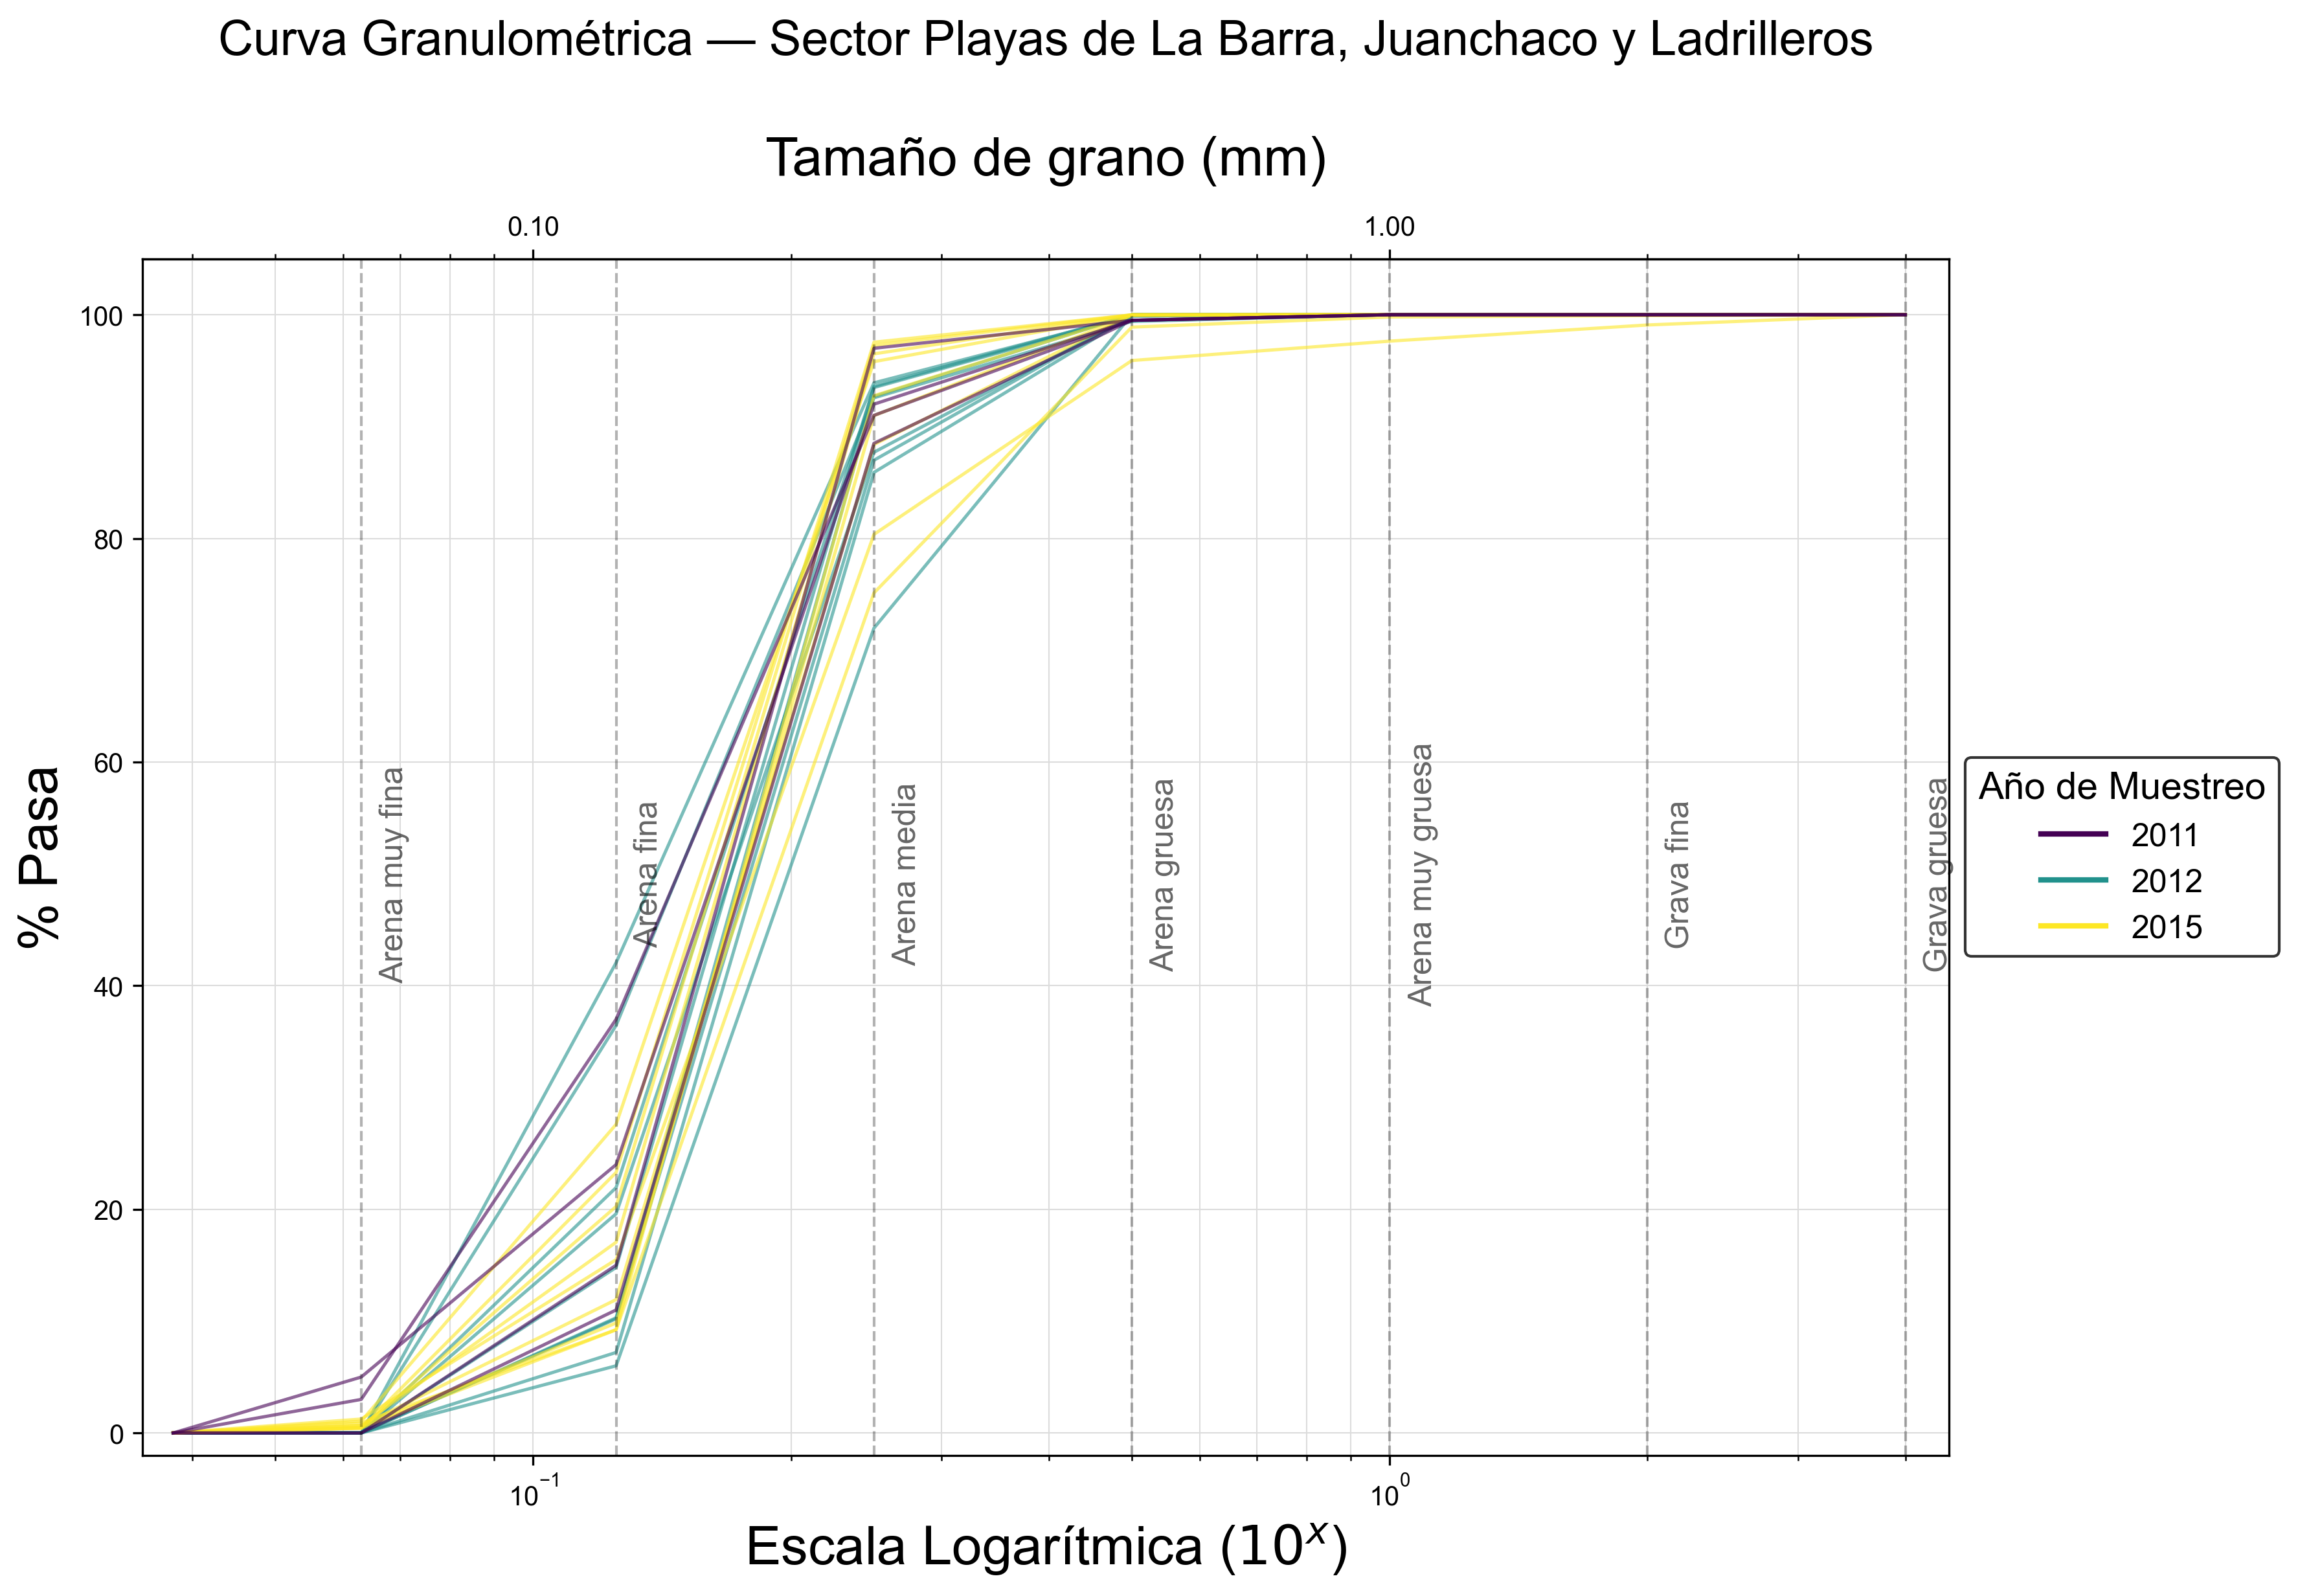

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter, LogFormatterMathtext
from html import unescape
from matplotlib.lines import Line2D # Importación necesaria para la leyenda personalizada

# =========================
# 0) PARÁMETROS DE ENTRADA
# =========================
file_path = r'C:\Users\usrlabima14\Documents\EDWARD_OSORIO\12_INVIAS\3_PRODUCTOS\PRODUCTO_2_CARACTERIZACION\imagenes\Granulometrias\Granulometrias\Juanchaco_ladrilleros_la_Barra_Choncho.xlsx'

# Modificado: Se deja vacío para graficar TODO. Se define la columna de color.
muestras_a_graficar = []  
col_muestras = 'MUESTRA'
col_color = 'AÑO' # Asegúrate de que en el Excel es 'AÑO' con tilde, o cámbialo aquí.

# =========================
# 1) CARGA Y LIMPIEZA BASE
# =========================
df = pd.read_excel(file_path).replace('-', 0).fillna(0)
df.columns = [unescape(str(c)).strip() for c in df.columns]

# Verificación de la columna de color
if col_color not in df.columns:
    raise KeyError(f"No se encontró la columna de agrupamiento '{col_color}' en el Excel. Verifica las mayúsculas/minúsculas o tildes.")

# --------------------------------------------
# 2) DEFINIR EL MAPEO (IGUAL)
# --------------------------------------------
MAPEO_CLASES_A_TAMICES = {
    '>4,0 mm'          : 'Grava_Fina',
    '2,0 - 4,0 mm'     : 'Grava_Muy_',
    '1,0 - 2,0 mm'     : 'Arena_Muy_',
    '0,5 - 1,0 mm'     : 'Arena_Grue',
    '0,25 - 0,5 mm'    : 'Arena_Medi',
    '0,125 - 0,25 mm'  : 'Arena_Fina',
    '0,063 - 0,125 mm' : 'Arena_Mu_f',
    '<0,063 mm'        : None
}

columnas_limos = ['Limo_Muy_G', 'Limo_Grues', 'Limo_Medio', 'Limo_Fino', 'Limo_Muy_F', 'Arcilla']
for col in columnas_limos:
    if col not in df.columns:
        df[col] = 0

df['<0,063 mm (calc)'] = df[columnas_limos].sum(axis=1)

# Sin discriminación de muestras (Graficar TODO)
df_plot = df.copy()

# =========================
# 3) CONFIGURACIÓN ESTÉTICA
# =========================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Open Sans Light', 'Arial']

config = {
    'titulo': "Curva Granulométrica — Sector Playas de La Barra, Juanchaco y Ladrilleros",
    'label_x_inf': "Escala Logarítmica ($10^x$)",
    'label_x_sup': "Tamaño de grano (mm)",
    'label_y': "% Pasa",
    'tam_fuente_labels': 20,
    'tam_fuente_ticks': 15,
    'color_grid': '#dcdcdc',
    'linea_ancho': 1.2, # Fina para manejar densidad de datos
}

aperturas = [4.0, 2.0, 1.0, 0.5, 0.25, 0.125, 0.063, 0.038]
tramos = ['>4,0 mm', '2,0 - 4,0 mm', '1,0 - 2,0 mm', '0,5 - 1,0 mm', '0,25 - 0,5 mm', '0,125 - 0,25 mm', '0,063 - 0,125 mm', '<0,063 mm']

def _norm(s: str) -> str:
    s = unescape(str(s)).strip().lower()
    return s.replace('\xa0', '').replace(' ', '').replace(',', '.')

def resolver_columna(df_cols, tramo_label, mapeo):
    if tramo_label == '<0,063 mm': return '<0,063 mm (calc)'
    col_src = mapeo.get(tramo_label)
    if not col_src: return tramo_label # Fallback
    nsrc = _norm(col_src)
    for c in df_cols:
        if _norm(c) == nsrc or nsrc in _norm(c): return c
    return col_src

cols_para_grafico = [resolver_columna(df.columns, t, MAPEO_CLASES_A_TAMICES) for t in tramos]

# --- NUEVO: Mapeo de Colores por Año ordenado ---
# Convertimos a entero para ordenar numéricamente, luego a string para la leyenda
df_plot[col_color] = pd.to_numeric(df_plot[col_color], errors='coerce').fillna(0).astype(int)
anios_unicos = sorted(df_plot[df_plot[col_color] > 0][col_color].unique())

cmap = plt.get_cmap('viridis') # Usamos viridis que es buena para daltónicos
# Generamos colores equitativos
if len(anios_unicos) > 0:
    colores_valores = cmap(np.linspace(0, 1, len(anios_unicos)))
    color_map = {anio: colores_valores[i] for i, anio in enumerate(anios_unicos)}
else:
    color_map = {}

# =================================
# 4) GRÁFICO
# =================================
fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

for _, row in df_plot.iterrows():
    # Cálculo de granulometría
    try:
        pesos = pd.to_numeric(row[cols_para_grafico], errors='coerce').fillna(0).values
        peso_total = pesos.sum()
        if peso_total == 0: continue
        
        retenido_acum = np.cumsum(pesos)
        porcentaje_pasa = np.clip(100.0 - (retenido_acum / peso_total * 100.0), 0, 100)

        # Color según el Año
        anio_row = row[col_color]
        color_linea = color_map.get(anio_row, 'gray') # Gris si el año no está mapeado

        ax.plot(
            aperturas, porcentaje_pasa, color=color_linea,
            linewidth=config['linea_ancho'], alpha=0.6 # Un poco de transparencia ayuda si hay muchas líneas
        )
    except Exception as e:
        continue # Salta muestras corruptas si las hay

# --- Referencias Wentworth ---
divisiones = {4.0: 'Grava gruesa', 2.0: 'Grava fina', 1.0: 'Arena muy gruesa', 0.5: 'Arena gruesa', 0.25: 'Arena media', 0.125: 'Arena fina', 0.063: 'Arena muy fina'}
for x, texto in divisiones.items():
    ax.axvline(x=x, color='black', linestyle='--', linewidth=1, alpha=0.3)
    ax.text(x * 1.05, 50, texto, rotation=90, va='center', ha='left', fontsize=12, alpha=0.6)

# --- Ejes y Formato ---
ax.set_xscale('log')
ax.set_xlim(4.5, 0.035)
ax.set_ylim(-2, 105)
ax.invert_xaxis()
ax.xaxis.set_major_formatter(LogFormatterMathtext())

secax = ax.secondary_xaxis('top')
secax.xaxis.set_major_formatter(ScalarFormatter())
secax.set_xlabel(config['label_x_sup'], fontsize=config['tam_fuente_labels'], labelpad=15)

ax.set_title(config['titulo'], fontsize=18, pad=30)
ax.set_xlabel(config['label_x_inf'], fontsize=config['tam_fuente_labels'])
ax.set_ylabel(config['label_y'], fontsize=config['tam_fuente_labels'])
ax.grid(True, which="both", color=config['color_grid'], linestyle='-', linewidth=0.5)

# =================================
# 5) CREAR LEYENDA POR AÑO (NUEVO)
# =================================
# Creamos elementos visuales "proxy" (líneas) que representan cada año
custom_lines = [
    Line2D([0], [0], color=color_map[anio], lw=2) for anio in anios_unicos
]

# Insertamos la leyenda usando esos elementos y los nombres de los años
if custom_lines:
    leg = ax.legend(
        custom_lines, 
        [str(anio) for anio in anios_unicos],
        title="Año de Muestreo",
        loc='center left',
        bbox_to_anchor=(1, 0.5), # Fuera del gráfico a la derecha
        fontsize=12,
        title_fontsize=14,
        frameon=True,
        edgecolor='black'
    )
    # Ajustamos alpha de las líneas de la leyenda para que se vean sólidas
    for lh in leg.legendHandles: 
        lh.set_alpha(1)

plt.tight_layout()
plt.show()

# CALCULO PARAMETROS ESTADÍSTICOS

In [3]:
import numpy as np
import pandas as pd

# ==========================================
# 1. FUNCIONES BASE
# ==========================================

def safe_div(a, b):
    """División segura para evitar errores"""
    return a / b if b != 0 else np.nan


# ==========================================
# 2. CLASIFICACIONES (Folk & Ward)
# ==========================================

def clasificar_sorting(s):
    if pd.isna(s): return "N/A"
    if s < 0.35: return "Very well sorted"
    if s < 0.50: return "Well sorted"
    if s < 0.71: return "Moderately well sorted"
    if s < 1.00: return "Moderately sorted"
    if s < 2.00: return "Poorly sorted"
    return "Very poorly sorted"


def clasificar_skewness(sk):
    if pd.isna(sk): return "N/A"
    if sk > 0.3: return "Strongly fine-skewed"
    if sk > 0.1: return "Fine-skewed"
    if sk > -0.1: return "Near symmetrical"
    if sk > -0.3: return "Coarse-skewed"
    return "Strongly coarse-skewed"


def clasificar_kurtosis(kg):
    if pd.isna(kg): return "N/A"
    if kg < 0.67: return "Very platykurtic"
    if kg < 0.90: return "Platykurtic"
    if kg < 1.11: return "Mesokurtic"
    if kg < 1.50: return "Leptokurtic"
    if kg < 3.00: return "Very leptokurtic"
    return "Extremely leptokurtic"


# ==========================================
# 3. ASEGURAR TIPO NUMÉRICO
# ==========================================

cols_fw = ['MEAN','SORTING','SKEWNESS','KURTOSIS']
df[cols_fw] = df[cols_fw].apply(pd.to_numeric, errors='coerce')


# ==========================================
# 4. CLASIFICACIONES DIRECTAS
# ==========================================

df['Clasificacion_Sorting'] = df['SORTING'].apply(clasificar_sorting)
df['Clasificacion_Skewness'] = df['SKEWNESS'].apply(clasificar_skewness)
df['Clasificacion_Kurtosis'] = df['KURTOSIS'].apply(clasificar_kurtosis)


# ==========================================
# 5. FUNCIONES DISCRIMINANTES (SAHU, 1964)
# ==========================================

def calcular_funciones_discriminantes(df):

    df['Y1'] = (
        -3.5688 * df['MEAN'] +
         3.7016 * df['SORTING'] -
         2.0766 * df['SKEWNESS'] +
         3.1135 * df['KURTOSIS']
    )

    df['Y2'] = (
        15.6534 * df['MEAN'] +
        65.7091 * df['SORTING'] +
        18.1071 * df['SKEWNESS'] +
        18.5043 * df['KURTOSIS']
    )

    df['Y3'] = (
         0.2852 * df['MEAN'] -
         8.7604 * df['SORTING'] -
         4.8932 * df['SKEWNESS'] +
         0.0482 * df['KURTOSIS']
    )

    df['Y4'] = (
         0.7215 * df['MEAN'] +
         0.4030 * df['SORTING'] +
         6.7322 * df['SKEWNESS'] +
         5.2927 * df['KURTOSIS']
    )

    return df


print("Calculando funciones discriminantes Y1, Y2, Y3 y Y4...")
df = calcular_funciones_discriminantes(df)
print("¡Funciones discriminantes calculadas!")


# ==========================================
# 6. INTERPRETACIÓN DE AMBIENTES
# ==========================================

def interpretar_Y1(y):
    if pd.isna(y): return "N/A"
    return "Aeolian" if y < -2.7411 else "Beach"

def interpretar_Y2(y):
    if pd.isna(y): return "N/A"
    return "Beach" if y < 65.3650 else "Shallow agitated marine"

def interpretar_Y3(y):
    if pd.isna(y): return "N/A"
    return "Fluvial" if y < -7.419 else "Shallow marine"

def interpretar_Y4(y):
    if pd.isna(y): return "N/A"
    return "Fluvial" if y < 10.0 else "Turbidity current"


df['Ambiente_Y1'] = df['Y1'].apply(interpretar_Y1)
df['Ambiente_Y2'] = df['Y2'].apply(interpretar_Y2)
df['Ambiente_Y3'] = df['Y3'].apply(interpretar_Y3)
df['Ambiente_Y4'] = df['Y4'].apply(interpretar_Y4)


# ==========================================
# 7. RESULTADO FINAL
# ==========================================

resultado = df[['PROYECTO','MUESTRA','AÑO',
                'MEAN',
                'SORTING','Clasificacion_Sorting',
                'SKEWNESS','Clasificacion_Skewness',
                'KURTOSIS','Clasificacion_Kurtosis',
                'Y1','Ambiente_Y1',
                'Y2','Ambiente_Y2',
                'Y3','Ambiente_Y3',
                'Y4','Ambiente_Y4']]


# ==========================================
# 8. EXPORTAR A EXCEL
# ==========================================

ruta_salida = "Resultados_Granulometria_Sahu.xlsx"

resultado.to_excel(ruta_salida, index=False)

print("Archivo exportado correctamente")
print(resultado.head(20))

Calculando funciones discriminantes Y1, Y2, Y3 y Y4...
¡Funciones discriminantes calculadas!
Archivo exportado correctamente
                                             PROYECTO       MUESTRA   AÑO  \
0                                        MADS-INVEMAR            19  2012   
1                                        MADS-INVEMAR            20  2012   
2                                        MADS-INVEMAR            21  2012   
3                                        MADS-INVEMAR            22  2012   
4                                        MADS-INVEMAR            23  2012   
5                                        MADS-INVEMAR            24  2012   
6                                        MADS-INVEMAR            25  2012   
7                                        MADS-INVEMAR            26  2012   
8                                        MADS-INVEMAR            27  2012   
9   EVOLUCIÓN RECIENTE DE LA ZONA COSTERA DEL DEPA...        LBR-01  2015   
10  EVOLUCIÓN RECIENTE DE LA

# DIAGRAMA DE BARRAS

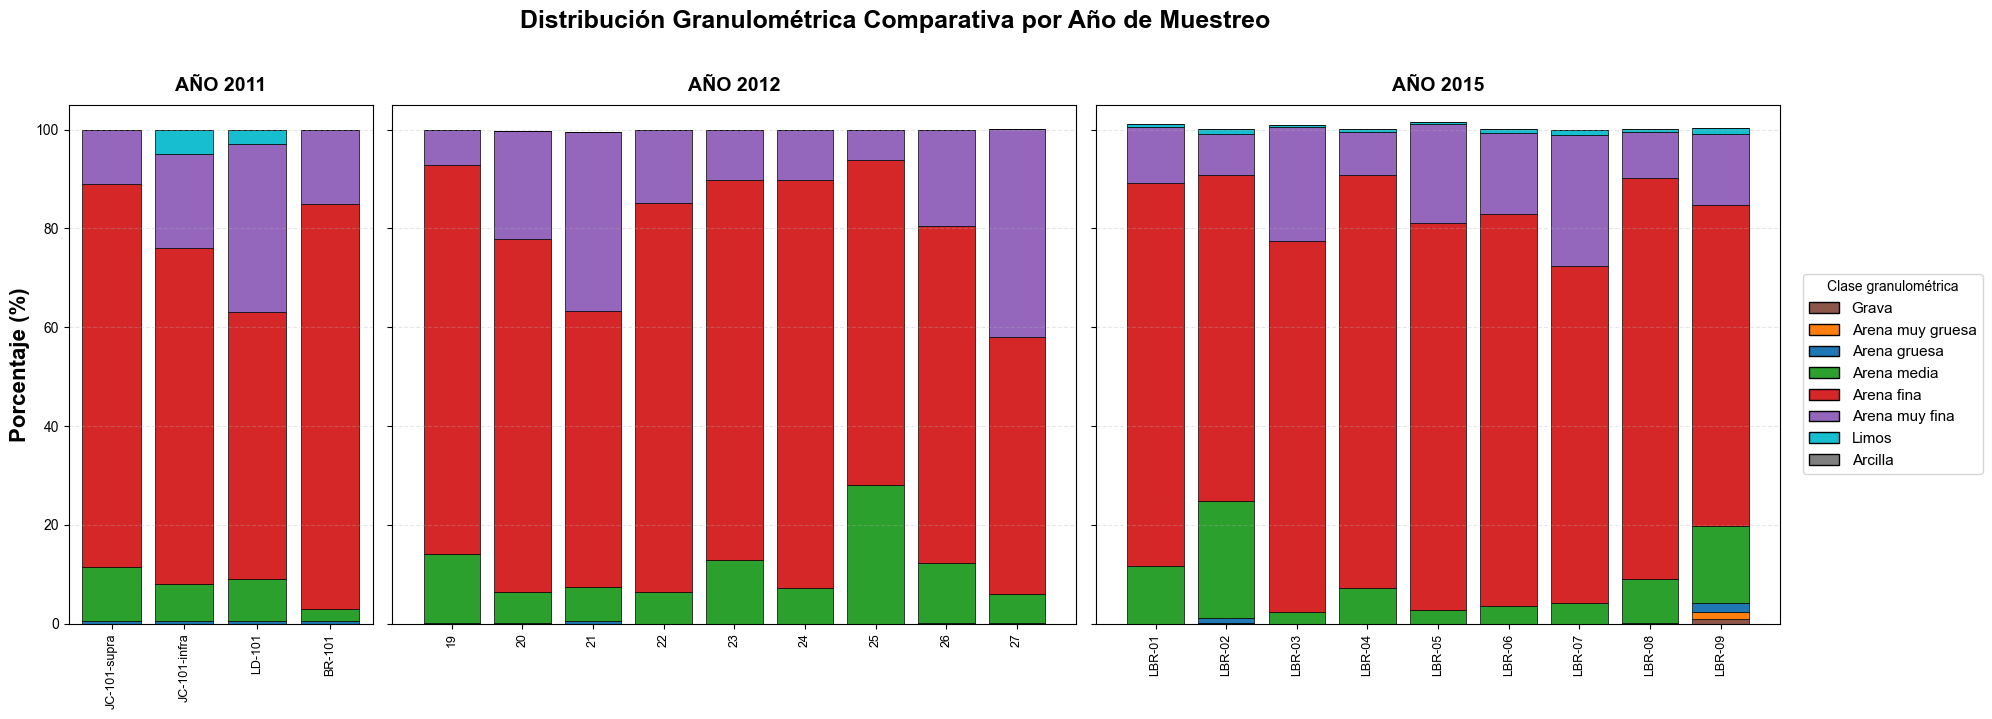

In [6]:
# ==========================================
# 1) PREPARACIÓN DE DATOS
# ==========================================
df_barras = df.copy()

# Agrupación de clases
df_barras['Grava'] = df_barras['Grava_Fina'] + df_barras['Grava_Muy_']
df_barras['Arena muy gruesa'] = df_barras['Arena_Muy_']
df_barras['Arena gruesa'] = df_barras['Arena_Grue']
df_barras['Arena media'] = df_barras['Arena_Medi']
df_barras['Arena fina'] = df_barras['Arena_Fina']
df_barras['Arena muy fina'] = df_barras['Arena_Mu_f']
df_barras['Limos'] = df_barras[['Limo_Muy_G', 'Limo_Grues', 'Limo_Medio', 'Limo_Fino', 'Limo_Muy_F']].sum(axis=1)
df_barras['Arcilla'] = df_barras['Arcilla']

clases = ['Grava', 'Arena muy gruesa', 'Arena gruesa', 'Arena media', 'Arena fina', 'Arena muy fina', 'Limos', 'Arcilla']
colors = ['#8c564b', '#ff7f0e', '#1f77b4', '#2ca02c', '#d62728', '#9467bd', '#17becf', '#7f7f7f']

# ==========================================
# 2) CREACIÓN DE FACETAS (SUBPLOTS)
# ==========================================
anios_lista = sorted(df_barras[col_color].unique())
n_anios = len(anios_lista)

fig, axes = plt.subplots(1, n_anios, figsize=(18, 7), sharey=True, 
                         gridspec_kw={'width_ratios': [len(df_barras[df_barras[col_color]==a]) for a in anios_lista]})

if n_anios == 1: axes = [axes] # Asegurar que sea lista si solo hay un año

for i, anio in enumerate(anios_lista):
    df_sub = df_barras[df_barras[col_color] == anio]
    ax = axes[i]
    bottom = np.zeros(len(df_sub))
    
    for clase, color in zip(clases, colors):
        valores = pd.to_numeric(df_sub[clase], errors='coerce').fillna(0).values
        ax.bar(df_sub[col_muestras].astype(str), valores, bottom=bottom, 
               color=color, edgecolor='k', linewidth=0.5)
        bottom += valores
    
    # Estética de cada sub-gráfico
    ax.set_title(f"AÑO {anio}", fontsize=14, fontweight='bold', pad=10)
    ax.tick_params(axis='x', rotation=90, labelsize=9)
    ax.set_ylim(0, 105)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

# Ejes globales
axes[0].set_ylabel('Porcentaje (%)', fontsize=16, fontweight='bold')
fig.suptitle('Distribución Granulométrica Comparativa por Año de Muestreo', fontsize=18, fontweight='bold', y=1.02)

# Leyenda única para toda la figura
handles, labels = axes[0].get_legend_handles_labels() # Esto es truco para sacar la leyenda de uno
# Como no pusimos label en el loop para no repetir, la creamos manual:
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, edgecolor='k', label=l) for c, l in zip(colors, clases)]

fig.legend(handles=legend_elements, title='Clase granulométrica', loc='center left', 
           bbox_to_anchor=(1.0, 0.5), fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

# SELECCION VS SIMETRIA

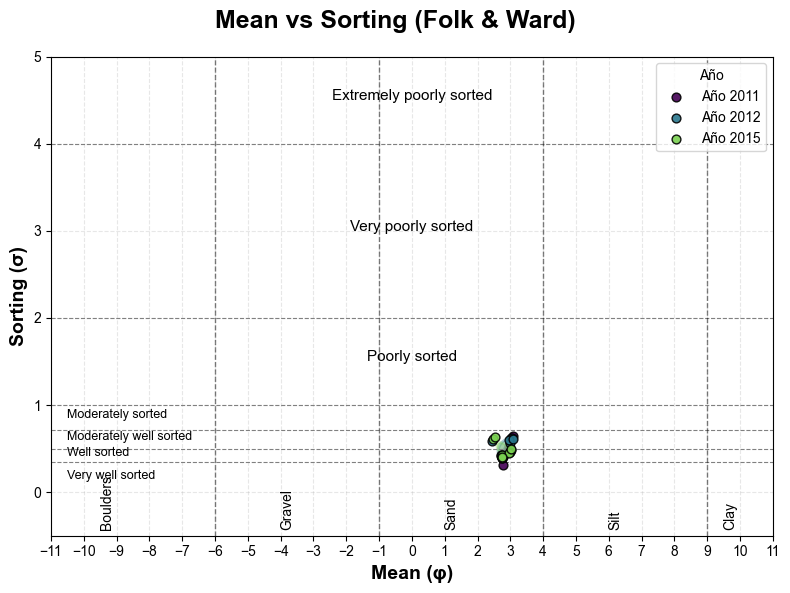

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pandas as pd

# ==========================================
# CONFIGURACIÓN
# ==========================================
col_color = 'AÑO'  # ← asegúrate que coincide con tu columna

# ==========================================
# FUNCIÓN: ELIPSE DE CONFIANZA
# ==========================================
def draw_confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):

    if len(x) < 2:
        return None

    cov = np.cov(x, y)

    if np.any(np.isnan(cov)):
        return None

    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    width, height = 2 * n_std * np.sqrt(vals)

    mean_x = np.mean(x)
    mean_y = np.mean(y)

    ellipse = Ellipse(
        (mean_x, mean_y),
        width=width,
        height=height,
        angle=theta,
        facecolor=facecolor,
        **kwargs
    )

    return ax.add_patch(ellipse)


# ==========================================
# 1) PREPARACIÓN DE DATOS (USANDO TUS COLUMNAS)
# ==========================================

df_plot = df.dropna(subset=['MEAN', 'SORTING']).copy()

# Asegurar tipo numérico
df_plot['MEAN'] = pd.to_numeric(df_plot['MEAN'], errors='coerce')
df_plot['SORTING'] = pd.to_numeric(df_plot['SORTING'], errors='coerce')
df_plot[col_color] = pd.to_numeric(df_plot[col_color], errors='coerce')

df_plot = df_plot.dropna(subset=['MEAN', 'SORTING', col_color])

anios_lista = sorted(df_plot[col_color].unique())

# ==========================================
# 2) COLORES
# ==========================================
cmap_v = plt.get_cmap('viridis')
color_map = {
    int(anio): cmap_v(i)
    for anio, i in zip(anios_lista, np.linspace(0, 0.8, len(anios_lista)))
}

# ==========================================
# 3) FIGURA
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', alpha=0.3)

# ==========================================
# 4) PUNTOS + ELIPSES
# ==========================================
for anio in anios_lista:

    df_sub = df_plot[df_plot[col_color] == anio]

    if df_sub.empty:
        continue

    color_p = color_map.get(int(anio))

    x = df_sub['MEAN'].values
    y = df_sub['SORTING'].values

    # --- ELIPSE ---
    if len(df_sub) > 2:
        draw_confidence_ellipse(
            x, y, ax,
            n_std=1.0,
            edgecolor=color_p,
            facecolor=color_p,
            alpha=0.35,
            linewidth=2,
            zorder=2
        )

    # --- PUNTOS ---
    ax.scatter(
        x, y,
        s=40,
        color=color_p,
        edgecolor='k',
        alpha=0.9,
        zorder=5,
        label=f'Año {int(anio)}'
    )

# ==========================================
# 5) LÍMITES
# ==========================================
ax.set_xlim(-11, 11)
ax.set_ylim(-0.5, 5.0)

# ==========================================
# 6) CLASIFICACIÓN SORTING
# ==========================================
sorting_lines = [0.35, 0.50, 0.71, 1.0, 2.0, 4.0]

for line in sorting_lines:
    ax.axhline(line, color='gray', linestyle='--', linewidth=0.8)

ax.text(-10.5, 0.15, 'Very well sorted', fontsize=9)
ax.text(-10.5, 0.42, 'Well sorted', fontsize=9)
ax.text(-10.5, 0.60, 'Moderately well sorted', fontsize=9)
ax.text(-10.5, 0.85, 'Moderately sorted', fontsize=9)
ax.text(0, 1.5, 'Poorly sorted', fontsize=11, ha='center')
ax.text(0, 3.0, 'Very poorly sorted', fontsize=11, ha='center')
ax.text(0, 4.5, 'Extremely poorly sorted', fontsize=11, ha='center')

# ==========================================
# 7) CLASIFICACIÓN MEAN (φ)
# ==========================================
for v in [-6, -1, 4, 9]:
    ax.axvline(v, color='black', linestyle='--', linewidth=1, alpha=0.5)

ax.text(-9.5, -0.4, 'Boulders', rotation=90, fontsize=10)
ax.text(-4.0, -0.4, 'Gravel', rotation=90, fontsize=10)
ax.text(1.0, -0.4, 'Sand', rotation=90, fontsize=10)
ax.text(6.0, -0.4, 'Silt', rotation=90, fontsize=10)
ax.text(9.5, -0.4, 'Clay', rotation=90, fontsize=10)

# ==========================================
# 8) EJES
# ==========================================
ax.set_xlabel('Mean (φ)', fontsize=14, fontweight='bold')
ax.set_ylabel('Sorting (σ)', fontsize=14, fontweight='bold')

ax.set_xticks(np.arange(-11, 12, 1))

# ==========================================
# 9) LEYENDA (SIN DUPLICADOS)
# ==========================================
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

ax.legend(
    by_label.values(),
    by_label.keys(),
    title="Año",
    loc='upper right',
    fontsize=10
)

# ==========================================
# 10) TÍTULO
# ==========================================
fig.suptitle(
    'Mean vs Sorting (Folk & Ward)',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

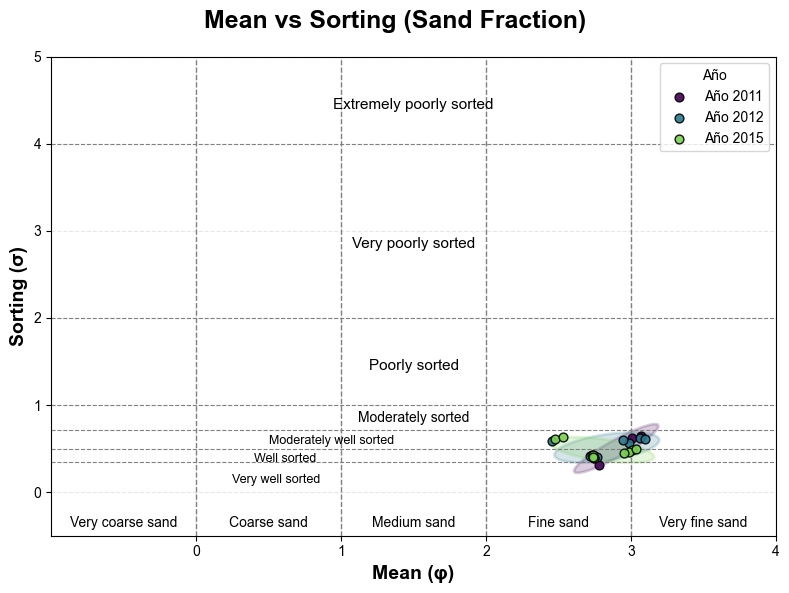

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pandas as pd

# ==========================================
# CONFIGURACIÓN
# ==========================================
col_color = 'AÑO'  # ← ajusta si tu columna se llama distinto

# ==========================================
# FUNCIÓN: ELIPSE DE CONFIANZA
# ==========================================
def draw_confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):

    if len(x) < 2:
        return None

    cov = np.cov(x, y)

    if np.any(np.isnan(cov)):
        return None

    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    width, height = 3.5 * n_std * np.sqrt(vals)

    ellipse = Ellipse(
        (np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=theta,
        facecolor=facecolor,
        **kwargs
    )

    return ax.add_patch(ellipse)


# ==========================================
# 1) PREPARACIÓN DE DATOS (CORREGIDO)
# ==========================================
df_plot = df.copy()

df_plot['MEAN'] = pd.to_numeric(df_plot['MEAN'], errors='coerce')
df_plot['SORTING'] = pd.to_numeric(df_plot['SORTING'], errors='coerce')
df_plot[col_color] = pd.to_numeric(df_plot[col_color], errors='coerce')

df_plot = df_plot.dropna(subset=['MEAN', 'SORTING', col_color])

anios_lista = sorted(df_plot[col_color].unique())

# ==========================================
# 2) COLORES
# ==========================================
cmap_v = plt.get_cmap('viridis')
color_map = {
    int(anio): cmap_v(i)
    for anio, i in zip(anios_lista, np.linspace(0, 0.8, len(anios_lista)))
}

# ==========================================
# 3) FIGURA
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', alpha=0.3)

# ==========================================
# 4) PUNTOS + ELIPSES
# ==========================================
for anio in anios_lista:

    df_sub = df_plot[df_plot[col_color] == anio]

    if df_sub.empty:
        continue

    color_p = color_map.get(int(anio))

    x = df_sub['MEAN'].values
    y = df_sub['SORTING'].values

    # ELIPSE
    if len(df_sub) > 2:
        draw_confidence_ellipse(
            x, y, ax,
            n_std=1.0,
            edgecolor=color_p,
            facecolor=color_p,
            alpha=0.2,
            linewidth=2,
            zorder=2
        )

    # PUNTOS
    ax.scatter(
        x, y,
        s=40,
        color=color_p,
        edgecolor='k',
        alpha=0.9,
        zorder=5,
        label=f'Año {int(anio)}'
    )

# ==========================================
# 5) LÍMITES
# ==========================================
ax.set_xlim(-1, 4)
ax.set_ylim(-0.5, 5.0)

# ==========================================
# 6) SORTING
# ==========================================
sorting_lines = [0.35, 0.50, 0.71, 1.0, 2.0, 4.0]

for line in sorting_lines:
    ax.axhline(line, color='gray', linestyle='--', linewidth=0.8)

ax.text(1.5, 4.4, 'Extremely poorly sorted', fontsize=11, ha='center')
ax.text(1.5, 2.8, 'Very poorly sorted', fontsize=11, ha='center')
ax.text(1.5, 1.4, 'Poorly sorted', fontsize=11, ha='center')
ax.text(1.5, 0.8, 'Moderately sorted', fontsize=10, ha='center')
ax.text(0.5, 0.55, 'Moderately well sorted', fontsize=9)
ax.text(0.4, 0.35, 'Well sorted', fontsize=9)
ax.text(0.25, 0.1, 'Very well sorted', fontsize=9)

# ==========================================
# 7) MEAN (ARENAS)
# ==========================================
for v in [0, 1, 2, 3]:
    ax.axvline(v, color='gray', linestyle='--', linewidth=1)

ax.text(-0.5, -0.4, 'Very coarse sand', fontsize=10, ha='center')
ax.text(0.5, -0.4, 'Coarse sand', fontsize=10, ha='center')
ax.text(1.5, -0.4, 'Medium sand', fontsize=10, ha='center')
ax.text(2.5, -0.4, 'Fine sand', fontsize=10, ha='center')
ax.text(3.5, -0.4, 'Very fine sand', fontsize=10, ha='center')

# ==========================================
# 8) EJES
# ==========================================
ax.set_xlabel('Mean (φ)', fontsize=14, fontweight='bold')
ax.set_ylabel('Sorting (σ)', fontsize=14, fontweight='bold')

ax.set_xticks(np.arange(0, 5, 1))

# ==========================================
# 9) LEYENDA SIN DUPLICADOS
# ==========================================
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

ax.legend(
    by_label.values(),
    by_label.keys(),
    title="Año",
    loc='upper right',
    fontsize=10
)

# ==========================================
# 10) TÍTULO
# ==========================================
fig.suptitle(
    'Mean vs Sorting (Sand Fraction)',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

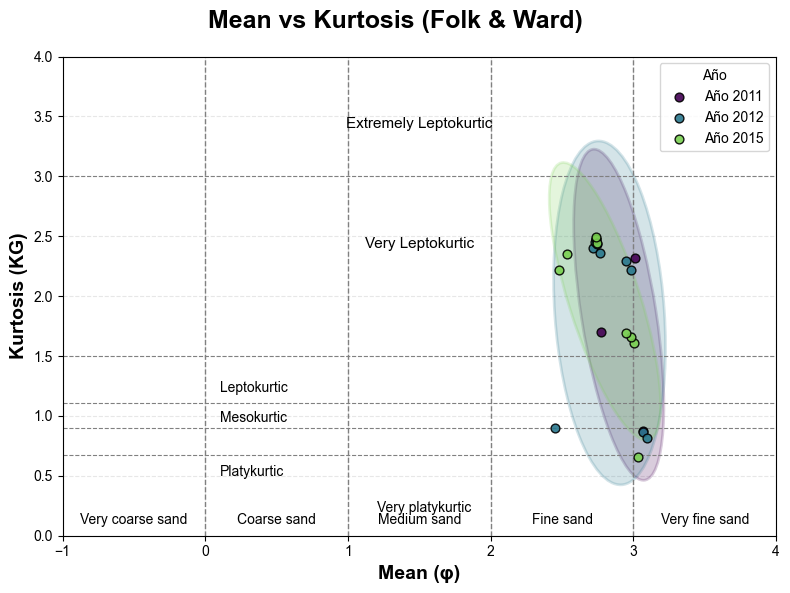

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pandas as pd

# ==========================================
# FUNCIÓN: ELIPSE DE CONFIANZA (CORRECTA)
# ==========================================
def draw_confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):
    if len(x) < 2:
        return None

    cov = np.cov(x, y)

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    width, height = 3.8 * n_std * np.sqrt(vals)

    mean_x = np.mean(x)
    mean_y = np.mean(y)

    ellipse = Ellipse(
        (mean_x, mean_y),
        width=width,
        height=height,
        angle=theta,
        facecolor=facecolor,
        **kwargs
    )

    return ax.add_patch(ellipse)


# ==========================================
# 1) PREPARACIÓN DE DATOS
# ==========================================
df_mean_kurt = df.dropna(subset=['Media_Mz', 'Kurtosis_KG']).copy()

df_mean_kurt[col_color] = pd.to_numeric(df_mean_kurt[col_color], errors='coerce')
df_mean_kurt = df_mean_kurt.dropna(subset=[col_color])

anios_lista = sorted(df_mean_kurt[col_color].unique())

# Colores por año
cmap_v = plt.get_cmap('viridis')
color_map = {
    int(anio): cmap_v(i)
    for anio, i in zip(anios_lista, np.linspace(0, 0.8, len(anios_lista)))
}

# ==========================================
# 2) FIGURA
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

ax.set_axisbelow(True)
ax.grid(True, which='both', linestyle='--', alpha=0.3)

# ==========================================
# 3) PUNTOS + ELIPSES POR AÑO
# ==========================================
for anio in anios_lista:

    df_sub = df_mean_kurt[df_mean_kurt[col_color] == anio]
    color_p = color_map.get(int(anio))

    x = df_sub['Media_Mz'].values
    y = df_sub['Kurtosis_KG'].values

    # --- ELIPSE ---
    if len(df_sub) > 2:
        draw_confidence_ellipse(
            x, y, ax,
            n_std=1.0,
            edgecolor=color_p,
            facecolor=color_p,
            alpha=0.2,
            linewidth=2,
            zorder=2
        )

    # --- PUNTOS ---
    ax.scatter(
        x, y,
        s=40,
        color=color_p,
        edgecolor='k',
        alpha=0.9,
        zorder=5,
        label=f'Año {int(anio)}'
    )

# ==========================================
# 4) LÍMITES (SEGÚN LA FIGURA)
# ==========================================
ax.set_xlim(-1, 4)
ax.set_ylim(0, 4)

# ==========================================
# 5) CLASIFICACIÓN KURTOSIS (IMAGEN)
# ==========================================
kurtosis_lines = [0.67, 0.90, 1.11, 1.50, 3.00]
for line in kurtosis_lines:
    ax.axhline(line, color='gray', linestyle='--', linewidth=0.8)

ax.text(1.5, 3.4, 'Extremely Leptokurtic', fontsize=11, ha='center')
ax.text(1.5, 2.4, 'Very Leptokurtic', fontsize=11, ha='center')
ax.text(0.1, 1.2, 'Leptokurtic', fontsize=10)
ax.text(0.1, 0.95, 'Mesokurtic', fontsize=10)
ax.text(0.1, 0., 'Platykurtic', fontsize=10)
ax.text(1.2, 0.3, 'Very platykurtic', fontsize=10)

# ==========================================
# 6) CLASIFICACIÓN MEAN (φ) – ARENAS
# ==========================================
for v in [0, 1, 2, 3]:
    ax.axvline(v, color='gray', linestyle='--', linewidth=1)

ax.text(-0.5, 0.05, 'Very coarse sand', fontsize=10, ha='center')
ax.text(0.5, 0.05, 'Coarse sand', fontsize=10, ha='center')
ax.text(1.5, 0.05, 'Medium sand', fontsize=10, ha='center')
ax.text(2.5, 0.05, 'Fine sand', fontsize=10, ha='center')
ax.text(3.5, 0.05, 'Very fine sand', fontsize=10, ha='center')

# ==========================================
# 7) EJES Y LEYENDA
# ==========================================
ax.set_xlabel('Mean (φ)', fontsize=14, fontweight='bold')
ax.set_ylabel('Kurtosis', fontsize=14, fontweight='bold')

ax.set_xticks(np.arange(-1, 5, 1))

ax.legend(
    title="Época de Muestreo",
    loc='upper right',
    fontsize=10
)

# ==========================================
# 8) TÍTULO
# ==========================================
fig.suptitle(
    'Diagrama de Clasificación: Media vs Kurtosis',
    fontsize=18,
    fontweight='bold',
    y=0.98
)

plt.tight_layout()
plt.show()

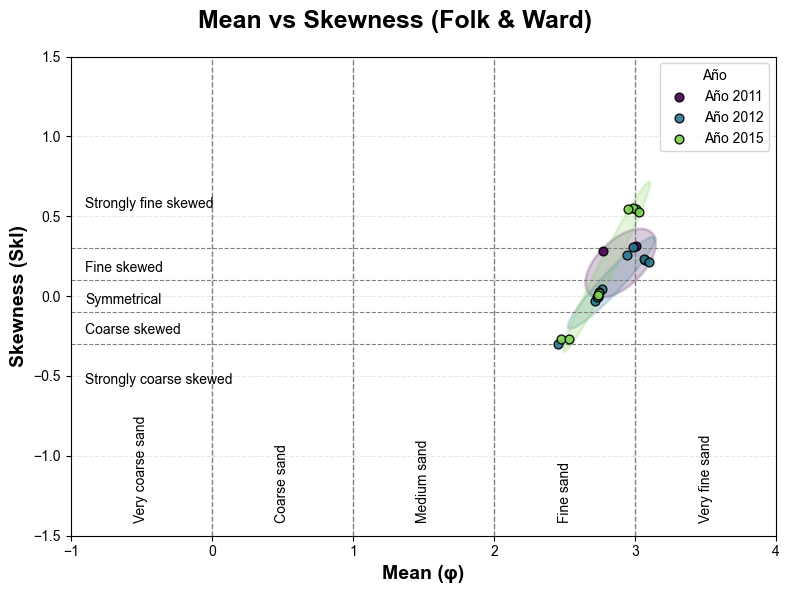

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pandas as pd

# ==========================================
# CONFIGURACIÓN
# ==========================================
col_color = 'AÑO'  # ← ajustar si cambia

# ==========================================
# FUNCIÓN: ELIPSE DE CONFIANZA
# ==========================================
def draw_confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):

    if len(x) < 2:
        return None

    cov = np.cov(x, y)

    if np.any(np.isnan(cov)):
        return None

    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    width, height = 3.0 * n_std * np.sqrt(vals)

    ellipse = Ellipse(
        (np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=theta,
        facecolor=facecolor,
        **kwargs
    )

    return ax.add_patch(ellipse)


# ==========================================
# 1) PREPARACIÓN DE DATOS (CORREGIDO)
# ==========================================
df_plot = df.copy()

df_plot['MEAN'] = pd.to_numeric(df_plot['MEAN'], errors='coerce')
df_plot['SKEWNESS'] = pd.to_numeric(df_plot['SKEWNESS'], errors='coerce')
df_plot[col_color] = pd.to_numeric(df_plot[col_color], errors='coerce')

df_plot = df_plot.dropna(subset=['MEAN', 'SKEWNESS', col_color])

anios_lista = sorted(df_plot[col_color].unique())

# ==========================================
# 2) COLORES
# ==========================================
cmap_v = plt.get_cmap('viridis')
color_map = {
    int(anio): cmap_v(i)
    for anio, i in zip(anios_lista, np.linspace(0, 0.8, len(anios_lista)))
}

# ==========================================
# 3) FIGURA
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', alpha=0.3)

# ==========================================
# 4) PUNTOS + ELIPSES
# ==========================================
for anio in anios_lista:

    df_sub = df_plot[df_plot[col_color] == anio]

    if df_sub.empty:
        continue

    color_p = color_map.get(int(anio))

    x = df_sub['MEAN'].values
    y = df_sub['SKEWNESS'].values

    # ELIPSE
    if len(df_sub) > 2:
        draw_confidence_ellipse(
            x, y, ax,
            n_std=1.0,
            edgecolor=color_p,
            facecolor=color_p,
            alpha=0.2,
            linewidth=2,
            zorder=2
        )

    # PUNTOS
    ax.scatter(
        x, y,
        s=40,
        color=color_p,
        edgecolor='k',
        alpha=0.9,
        zorder=5,
        label=f'Año {int(anio)}'
    )

# ==========================================
# 5) LÍMITES
# ==========================================
ax.set_xlim(-1, 4)
ax.set_ylim(-1.5, 1.5)

# ==========================================
# 6) SKEWNESS
# ==========================================
skew_lines = [-0.3, -0.1, 0.1, 0.3]

for line in skew_lines:
    ax.axhline(line, color='gray', linestyle='--', linewidth=0.8)

ax.text(-0.9, 0.55, 'Strongly fine skewed', fontsize=10)
ax.text(-0.9, 0.15, 'Fine skewed', fontsize=10)
ax.text(-0.9, -0.05, 'Symmetrical', fontsize=10)
ax.text(-0.9, -0.24, 'Coarse skewed', fontsize=10)
ax.text(-0.9, -0.55, 'Strongly coarse skewed', fontsize=10)

# ==========================================
# 7) MEAN (ARENAS)
# ==========================================
for v in [0, 1, 2, 3]:
    ax.axvline(v, color='gray', linestyle='--', linewidth=1)

ax.text(-0.5, -1.4, 'Very coarse sand', fontsize=10, ha='center', rotation=90)
ax.text(0.5, -1.4, 'Coarse sand', fontsize=10, ha='center', rotation=90)
ax.text(1.5, -1.4, 'Medium sand', fontsize=10, ha='center', rotation=90)
ax.text(2.5, -1.4, 'Fine sand', fontsize=10, ha='center', rotation=90)
ax.text(3.5, -1.4, 'Very fine sand', fontsize=10, ha='center', rotation=90)

# ==========================================
# 8) EJES
# ==========================================
ax.set_xlabel('Mean (φ)', fontsize=14, fontweight='bold')
ax.set_ylabel('Skewness (SkI)', fontsize=14, fontweight='bold')

ax.set_xticks(np.arange(-1, 5, 1))

# ==========================================
# 9) LEYENDA LIMPIA
# ==========================================
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

ax.legend(
    by_label.values(),
    by_label.keys(),
    title="Año",
    loc='upper right',
    fontsize=10
)

# ==========================================
# 10) TÍTULO
# ==========================================
fig.suptitle(
    'Mean vs Skewness (Folk & Ward)',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# LINEAR DISCRIMINATION FUNCTIONS

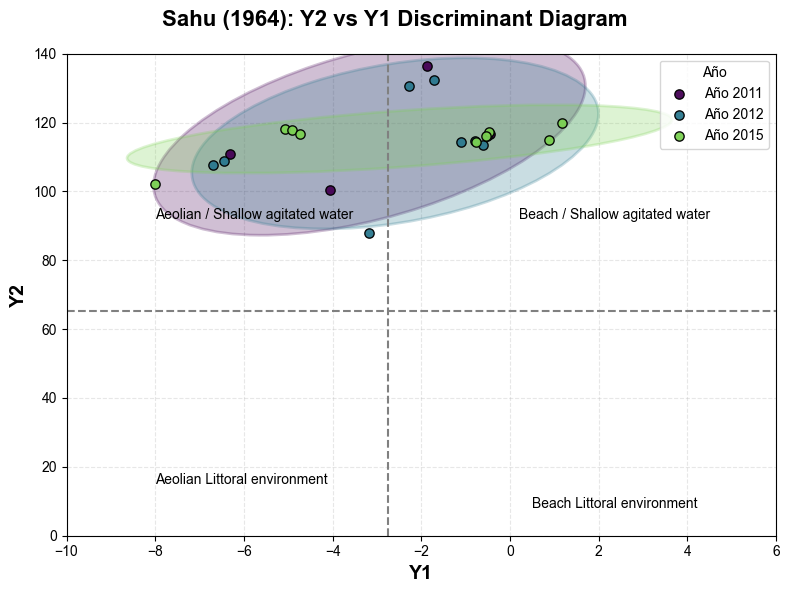

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pandas as pd

# ==========================================
# CONFIGURACIÓN
# ==========================================
col_color = 'AÑO'  # ← ajustar si cambia

# ==========================================
# FUNCIÓN: ELIPSE DE CONFIANZA
# ==========================================
def draw_confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):

    if len(x) < 2:
        return None

    cov = np.cov(x, y)

    if np.any(np.isnan(cov)):
        return None

    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    width, height = 3.8 * n_std * np.sqrt(vals)

    ellipse = Ellipse(
        (np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=theta,
        facecolor=facecolor,
        **kwargs
    )

    return ax.add_patch(ellipse)


# ==========================================
# 1) PREPARACIÓN DE DATOS
# ==========================================
df_plot = df.copy()

df_plot['Y1'] = pd.to_numeric(df_plot['Y1'], errors='coerce')
df_plot['Y2'] = pd.to_numeric(df_plot['Y2'], errors='coerce')
df_plot[col_color] = pd.to_numeric(df_plot[col_color], errors='coerce')

df_plot = df_plot.dropna(subset=['Y1', 'Y2', col_color])

anios_lista = sorted(df_plot[col_color].unique())

# ==========================================
# 2) COLORES
# ==========================================
cmap_v = plt.get_cmap('viridis')
color_map = {
    int(anio): cmap_v(i)
    for anio, i in zip(anios_lista, np.linspace(0, 0.8, len(anios_lista)))
}

# ==========================================
# 3) FIGURA
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', alpha=0.3)

# ==========================================
# 4) PUNTOS + ELIPSES
# ==========================================
for anio in anios_lista:

    df_sub = df_plot[df_plot[col_color] == anio]

    if df_sub.empty:
        continue

    color_p = color_map.get(int(anio))

    x = df_sub['Y1'].values
    y = df_sub['Y2'].values

    # ELIPSE
    if len(df_sub) > 2:
        draw_confidence_ellipse(
            x, y, ax,
            edgecolor=color_p,
            facecolor=color_p,
            alpha=0.25,
            linewidth=2,
            zorder=2
        )

    # PUNTOS
    ax.scatter(
        x, y,
        s=45,
        color=color_p,
        edgecolor='k',
        alpha=0.95,
        zorder=5,
        label=f'Año {int(anio)}'
    )

# ==========================================
# 5) LÍMITES
# ==========================================
ax.set_xlim(-10, 6)
ax.set_ylim(0, 140)

# ==========================================
# 6) LÍNEAS SAHU
# ==========================================
ax.axvline(-2.7411, color='gray', linestyle='--', linewidth=1.5)
ax.axhline(65.3650, color='gray', linestyle='--', linewidth=1.5)

# ==========================================
# 7) CAMPOS INTERPRETATIVOS
# ==========================================
ax.text(-8.0, 92, 'Aeolian / Shallow agitated water', fontsize=10)
ax.text(0.2, 92, 'Beach / Shallow agitated water', fontsize=10)

ax.text(0.5, 8, 'Beach Littoral environment', fontsize=10)
ax.text(-8.0, 15, 'Aeolian Littoral environment', fontsize=10)

# ==========================================
# 8) EJES
# ==========================================
ax.set_xlabel('Y1', fontsize=14, fontweight='bold')
ax.set_ylabel('Y2', fontsize=14, fontweight='bold')

# ==========================================
# 9) LEYENDA LIMPIA
# ==========================================
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

ax.legend(
    by_label.values(),
    by_label.keys(),
    title="Año",
    loc='upper right',
    fontsize=10
)

# ==========================================
# 10) TÍTULO
# ==========================================
fig.suptitle(
    'Sahu (1964): Y2 vs Y1 Discriminant Diagram',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

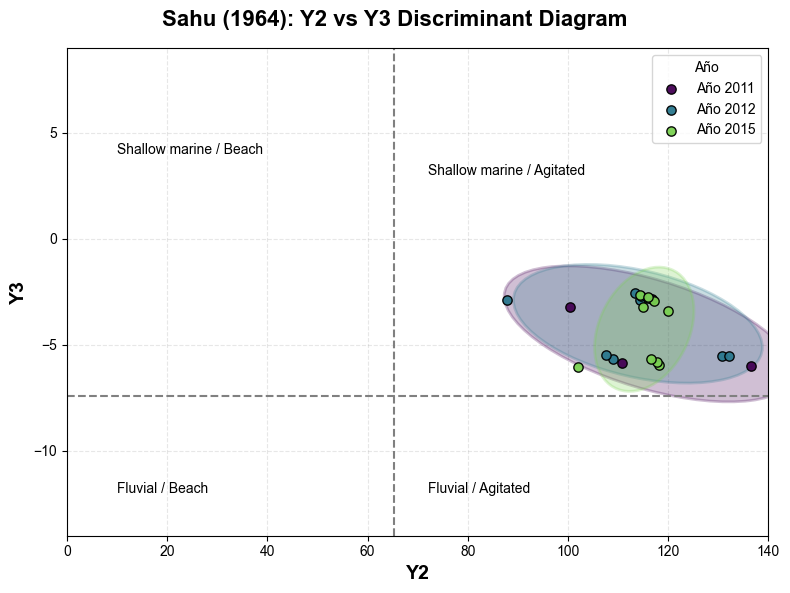

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pandas as pd

# ==========================================
# CONFIGURACIÓN
# ==========================================
col_color = 'AÑO'  # ← ajustar si cambia

# ==========================================
# FUNCIÓN: ELIPSE DE CONFIANZA
# ==========================================
def draw_confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):

    if len(x) < 2:
        return None

    cov = np.cov(x, y)

    if np.any(np.isnan(cov)):
        return None

    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    width, height = 3.8 * n_std * np.sqrt(vals)

    ellipse = Ellipse(
        (np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=theta,
        facecolor=facecolor,
        **kwargs
    )

    return ax.add_patch(ellipse)


# ==========================================
# 1) PREPARACIÓN DE DATOS
# ==========================================
df_plot = df.copy()

df_plot['Y2'] = pd.to_numeric(df_plot['Y2'], errors='coerce')
df_plot['Y3'] = pd.to_numeric(df_plot['Y3'], errors='coerce')
df_plot[col_color] = pd.to_numeric(df_plot[col_color], errors='coerce')

df_plot = df_plot.dropna(subset=['Y2', 'Y3', col_color])

anios_lista = sorted(df_plot[col_color].unique())

# ==========================================
# 2) COLORES
# ==========================================
cmap_v = plt.get_cmap('viridis')
color_map = {
    int(anio): cmap_v(i)
    for anio, i in zip(anios_lista, np.linspace(0, 0.8, len(anios_lista)))
}

# ==========================================
# 3) FIGURA
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', alpha=0.3)

# ==========================================
# 4) PUNTOS + ELIPSES
# ==========================================
for anio in anios_lista:

    df_sub = df_plot[df_plot[col_color] == anio]

    if df_sub.empty:
        continue

    color_p = color_map.get(int(anio))

    x = df_sub['Y2'].values
    y = df_sub['Y3'].values

    # ELIPSE
    if len(df_sub) > 2:
        draw_confidence_ellipse(
            x, y, ax,
            edgecolor=color_p,
            facecolor=color_p,
            alpha=0.25,
            linewidth=2,
            zorder=2
        )

    # PUNTOS
    ax.scatter(
        x, y,
        s=45,
        color=color_p,
        edgecolor='k',
        alpha=0.95,
        zorder=5,
        label=f'Año {int(anio)}'
    )

# ==========================================
# 5) LÍMITES
# ==========================================
ax.set_xlim(0, 140)
ax.set_ylim(-14, 9)

# ==========================================
# 6) LÍNEAS SAHU
# ==========================================
ax.axvline(65.365, color='gray', linestyle='--', linewidth=1.5)
ax.axhline(-7.419, color='gray', linestyle='--', linewidth=1.5)

# ==========================================
# 7) CAMPOS INTERPRETATIVOS
# ==========================================
ax.text(10, 4, 'Shallow marine / Beach', fontsize=10)
ax.text(72, 3, 'Shallow marine / Agitated', fontsize=10)

ax.text(10, -12, 'Fluvial / Beach', fontsize=10)
ax.text(72, -12, 'Fluvial / Agitated', fontsize=10)

# ==========================================
# 8) EJES
# ==========================================
ax.set_xlabel('Y2', fontsize=14, fontweight='bold')
ax.set_ylabel('Y3', fontsize=14, fontweight='bold')

# ==========================================
# 9) LEYENDA LIMPIA
# ==========================================
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

ax.legend(
    by_label.values(),
    by_label.keys(),
    title="Año",
    loc='upper right',
    fontsize=10
)

# ==========================================
# 10) TÍTULO
# ==========================================
fig.suptitle(
    'Sahu (1964): Y2 vs Y3 Discriminant Diagram',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

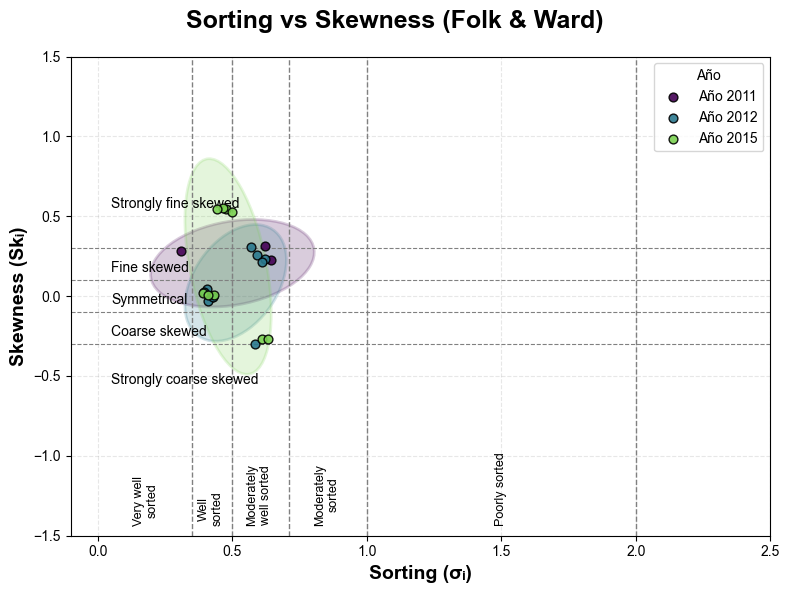

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import pandas as pd

# ==========================================
# CONFIGURACIÓN
# ==========================================
col_color = 'AÑO'  # ← ajustar si cambia

# ==========================================
# FUNCIÓN: ELIPSE DE CONFIANZA
# ==========================================
def draw_confidence_ellipse(x, y, ax, n_std=1.0, facecolor='none', **kwargs):

    if len(x) < 2:
        return None

    cov = np.cov(x, y)

    if np.any(np.isnan(cov)):
        return None

    vals, vecs = np.linalg.eigh(cov)

    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    width, height = 3.8 * n_std * np.sqrt(vals)

    ellipse = Ellipse(
        (np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=theta,
        facecolor=facecolor,
        **kwargs
    )

    return ax.add_patch(ellipse)


# ==========================================
# 1) PREPARACIÓN DE DATOS (CORREGIDO)
# ==========================================
df_plot = df.copy()

df_plot['SORTING'] = pd.to_numeric(df_plot['SORTING'], errors='coerce')
df_plot['SKEWNESS'] = pd.to_numeric(df_plot['SKEWNESS'], errors='coerce')
df_plot[col_color] = pd.to_numeric(df_plot[col_color], errors='coerce')

df_plot = df_plot.dropna(subset=['SORTING', 'SKEWNESS', col_color])

anios_lista = sorted(df_plot[col_color].unique())

# ==========================================
# 2) COLORES
# ==========================================
cmap_v = plt.get_cmap('viridis')
color_map = {
    int(anio): cmap_v(i)
    for anio, i in zip(anios_lista, np.linspace(0, 0.8, len(anios_lista)))
}

# ==========================================
# 3) FIGURA
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6))

ax.set_axisbelow(True)
ax.grid(True, linestyle='--', alpha=0.3)

# ==========================================
# 4) PUNTOS + ELIPSES
# ==========================================
for anio in anios_lista:

    df_sub = df_plot[df_plot[col_color] == anio]

    if df_sub.empty:
        continue

    color_p = color_map.get(int(anio))

    x = df_sub['SORTING'].values
    y = df_sub['SKEWNESS'].values

    # ELIPSE
    if len(df_sub) > 2:
        draw_confidence_ellipse(
            x, y, ax,
            edgecolor=color_p,
            facecolor=color_p,
            alpha=0.2,
            linewidth=2,
            zorder=2
        )

    # PUNTOS
    ax.scatter(
        x, y,
        s=40,
        color=color_p,
        edgecolor='k',
        alpha=0.9,
        zorder=5,
        label=f'Año {int(anio)}'
    )

# ==========================================
# 5) LÍMITES
# ==========================================
ax.set_xlim(-0.1, 2.5)
ax.set_ylim(-1.5, 1.5)

# ==========================================
# 6) SKEWNESS
# ==========================================
skew_lines = [-0.3, -0.1, 0.1, 0.3]

for line in skew_lines:
    ax.axhline(line, color='gray', linestyle='--', linewidth=0.8)

ax.text(0.05, 0.55, 'Strongly fine skewed', fontsize=10)
ax.text(0.05, 0.15, 'Fine skewed', fontsize=10)
ax.text(0.05, -0.05, 'Symmetrical', fontsize=10)
ax.text(0.05, -0.25, 'Coarse skewed', fontsize=10)
ax.text(0.05, -0.55, 'Strongly coarse skewed', fontsize=10)

# ==========================================
# 7) SORTING
# ==========================================
sorting_lines = [0.35, 0.50, 0.71, 1.0, 2.0]

for s in sorting_lines:
    ax.axvline(s, color='gray', linestyle='--', linewidth=1)

ax.text(0.18, -1.42, 'Very well\nsorted', fontsize=9, ha='center', rotation=90)
ax.text(0.42, -1.42, 'Well\nsorted', fontsize=9, ha='center', rotation=90)
ax.text(0.60, -1.42, 'Moderately\nwell sorted', fontsize=9, ha='center', rotation=90)
ax.text(0.85, -1.42, 'Moderately\nsorted', fontsize=9, ha='center', rotation=90)
ax.text(1.5, -1.42, 'Poorly sorted', fontsize=9, ha='center', rotation=90)

# ==========================================
# 8) EJES
# ==========================================
ax.set_xlabel('Sorting (σᵢ)', fontsize=14, fontweight='bold')
ax.set_ylabel('Skewness (Skᵢ)', fontsize=14, fontweight='bold')

# ==========================================
# 9) LEYENDA LIMPIA
# ==========================================
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

ax.legend(
    by_label.values(),
    by_label.keys(),
    title="Año",
    loc='upper right',
    fontsize=10
)

# ==========================================
# 10) TÍTULO
# ==========================================
fig.suptitle(
    'Sorting vs Skewness (Folk & Ward)',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()


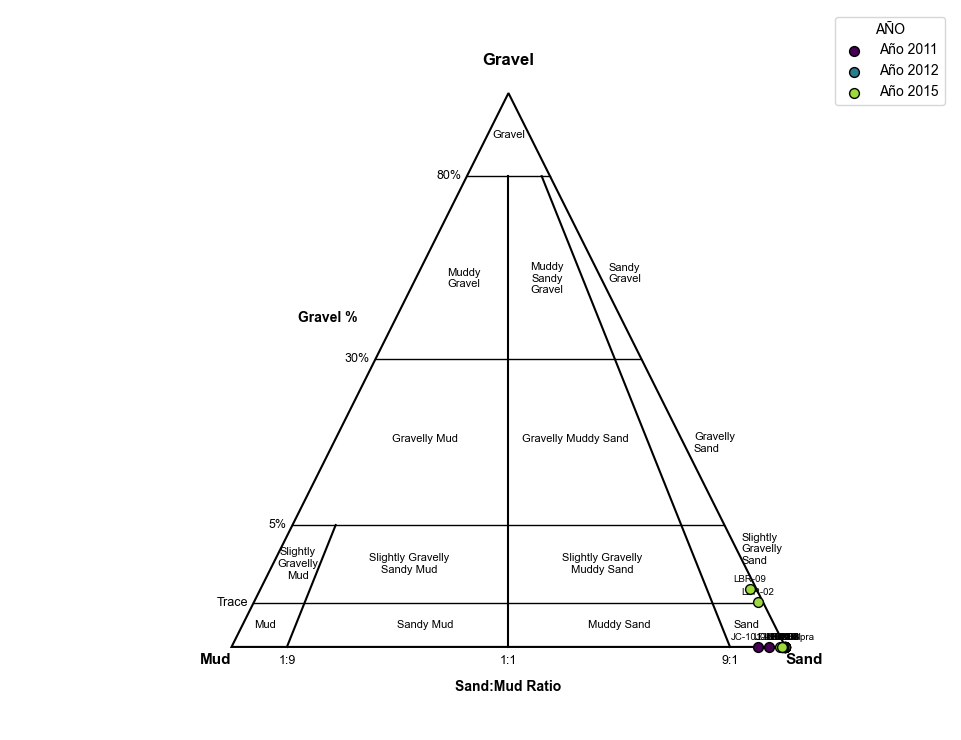

In [40]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd

# ==============================
# 1. LIMPIEZA DE COLUMNAS
# ==============================
df.columns = df.columns.str.strip()

cols_req = ['%_GRAVEL', '%_SAND', '%_MUD', 'AÑO']
faltantes = [c for c in cols_req if c not in df.columns]

if faltantes:
    raise ValueError(f"Faltan columnas: {faltantes}\nColumnas disponibles: {list(df.columns)}")

# Convertir a numérico
for col in ['%_GRAVEL', '%_SAND', '%_MUD', 'AÑO']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=cols_req)

# Normalizar a 100%
df[['%_GRAVEL', '%_SAND', '%_MUD']] = df[['%_GRAVEL', '%_SAND', '%_MUD']].div(
    df[['%_GRAVEL', '%_SAND', '%_MUD']].sum(axis=1), axis=0
) * 100


# ==============================
# 2. FUNCIONES
# ==============================
def to_y(val):
    if val <= 0.01:
        return (val / 0.01) * 8
    elif val <= 5:
        return 8 + (val - 0.01) * (22 - 8) / (5 - 0.01)
    elif val <= 30:
        return 22 + (val - 5) * (52 - 22) / (30 - 5)
    elif val <= 80:
        return 52 + (val - 30) * (85 - 52) / (80 - 30)
    else:
        return 85 + (val - 80) * (100 - 85) / (100 - 80)


def ternary_to_xy(gravel, sand, mud):
    y = to_y(gravel)
    ancho = 100 * (1 - y / 100)

    ratio = 0 if (sand + mud) == 0 else sand / (sand + mud)
    x = (100 - ancho) / 2 + ratio * ancho

    return x, y


# ==============================
# 3. FUNCIÓN PRINCIPAL
# ==============================
def draw_folk_with_data(df):

    fig, ax = plt.subplots(figsize=(12, 7.5))
    h_tri = 100 

    # --- Triángulo base ---
    ax.add_patch(patches.Polygon(
        [[0, 0], [50, h_tri], [100, 0]],
        closed=True,
        facecolor='white',
        edgecolor='black',
        linewidth=1.5
    ))

    # --- Líneas horizontales ---
    niveles = [0.01, 5, 30, 80]
    labels = {0.01: 'Trace', 5: '5%', 30: '30%', 80: '80%'}

    for n in niveles:
        y_c = to_y(n)
        ancho = 100 * (1 - y_c/h_tri)
        x_s, x_e = (100 - ancho)/2, 100 - (100 - ancho)/2

        ax.plot([x_s, x_e], [y_c, y_c], color='black', linewidth=1)

        if n in labels:
            ax.text(x_s - 1, y_c, labels[n],
                    ha='right', va='center', fontsize=9)

    # --- Líneas de ratio ---
    def get_x_at_y(x_base, y_target):
        return x_base + (50 - x_base) * (y_target / h_tri)

    ax.plot([10, get_x_at_y(10, to_y(5))], [0, to_y(5)], color='black')
    for r in [50, 90]:
        ax.plot([r, get_x_at_y(r, to_y(80))], [0, to_y(80)], color='black')

    # --- Texto interno ---
    s = {'ha': 'center', 'va': 'center', 'fontsize': 8}

    ax.text(50, to_y(90), "Gravel", **s)
    ax.text(42, to_y(52), "Muddy\nGravel", **s)
    ax.text(57, to_y(52), "Muddy\nSandy\nGravel", **s)
    ax.text(35, to_y(18), "Gravelly Mud", **s)
    ax.text(62, to_y(18), "Gravelly Muddy Sand", **s)
    ax.text(68, to_y(51), "Sandy\nGravel", ha='left', fontsize=8) # Nueva
    ax.text(83.5, to_y(16), "Gravelly\nSand", ha='left', fontsize=8) # Nueva

    y_sg_text = to_y(2.5)
    ax.text(12, y_sg_text, "Slightly\nGravelly\nMud", **s)
    ax.text(32, y_sg_text, "Slightly Gravelly\nSandy Mud", **s)
    ax.text(67, y_sg_text, "Slightly Gravelly\nMuddy Sand", **s)
    ax.text(92, y_sg_text, "Slightly\nGravelly\nSand", ha='left', fontsize=8) # Nueva

    ax.text(6, 4, "Mud", **s)
    ax.text(35, 4, "Sandy Mud", **s)
    ax.text(70, 4, "Muddy Sand", **s)
    ax.text(93, 4, "Sand", **s)

    # --- Ejes ---
    ax.text(50, 105, 'Gravel', ha='center', weight='bold', fontsize=12)
    ax.text(12, to_y(40), 'Gravel %', weight='bold', fontsize=10)
    ax.text(0, -3, 'Mud', ha='right', weight='bold', fontsize=11)
    ax.text(100, -3, 'Sand', ha='left', weight='bold', fontsize=11)
    ax.text(50, -8, 'Sand:Mud Ratio', ha='center', weight='bold', fontsize=10)

    for r, lab in zip([10, 50, 90], ['1:9', '1:1', '9:1']):
        ax.text(r, -3, lab, ha='center', fontsize=9)

    # ==============================
    # 4. COLORES POR AÑO
    # ==============================
    anios = sorted(df['AÑO'].unique())
    cmap = plt.get_cmap('viridis')

    color_map = {
        anio: cmap(i)
        for anio, i in zip(anios, np.linspace(0, 0.85, len(anios)))
    }

    # ==============================
    # 5. PLOT POR GRUPOS
    # ==============================
    for anio in anios:

        df_sub = df[df['AÑO'] == anio]
        color = color_map[anio]

        x_vals = []
        y_vals = []

        for _, row in df_sub.iterrows():
            x, y = ternary_to_xy(
                row['%_GRAVEL'],
                row['%_SAND'],
                row['%_MUD']
            )
            x_vals.append(x)
            y_vals.append(y)

            if 'MUESTRA' in df.columns:
                ax.text(x, y + 1.2, str(row['MUESTRA']),
                        fontsize=7, ha='center')

        ax.scatter(
            x_vals, y_vals,
            s=50,
            color=color,
            edgecolor='k',
            label=f'Año {int(anio)}',
            zorder=5
        )

    # --- Ajustes ---
    ax.set_xlim(-40, 130)
    ax.set_ylim(-15, 115)
    ax.set_aspect('equal')
    ax.axis('off')

    ax.legend(title='AÑO', loc='upper right')

    plt.tight_layout()
    plt.show()


# ==============================
# 6. EJECUCIÓN
# ==============================
draw_folk_with_data(df)